<a href="https://colab.research.google.com/github/sohampalav/MyWebPage/blob/main/CSL701_CE34Machine_Learning_exp3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



# Machine Learning Experiment Number 3

\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [2]:
import numpy as np
import matplotlib.pyplot as plt

print("Python environment setup completed successfully.")
print("NumPy version:", np.__version__)
print("Matplotlib imported successfully.")

Python environment setup completed successfully.
NumPy version: 2.0.2
Matplotlib imported successfully.


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [6]:
from google.colab import files
import pandas as pd

# Upload CSV file
uploaded = files.upload()

# Get the uploaded filename
filename = next(iter(uploaded))

# Load the dataset
df = pd.read_csv(filename)

# Display first 5 records
print("First 5 records:")
display(df.head())

# Display number of rows and columns
print("\nNumber of rows and columns:")
print(df.shape)

# Display column names
print("\nColumn names:")
print(df.columns.tolist())

Saving cardekho_dataset.csv to cardekho_dataset.csv
First 5 records:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000



Number of rows and columns:
(15411, 14)

Column names:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [7]:
# Task 3: Check and Handle Missing Data

# 1. Check for missing/null values in every column
print("Missing values before preprocessing:")
print(df.isnull().sum())

# 2. Display total number of missing values
print("\nTotal missing values:")
print(df.isnull().sum().sum())

# 3. Handle missing values
# Numerical columns: replace missing values with median
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

for column in numerical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].median())

# Categorical columns: replace missing values with mode
categorical_columns = df.select_dtypes(include=["object"]).columns

for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])

# 4. Verify that no missing values remain
print("\nMissing values after preprocessing:")
print(df.isnull().sum())

print("\nTotal missing values after preprocessing:")
print(df.isnull().sum().sum())

# 5. Final verification
if df.isnull().sum().sum() == 0:
    print("\nNo missing values remain in the dataset.")
else:
    print("\nMissing values are still present.")

Missing values before preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values:
0

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values after preprocessing:
0

No missing values remain in the dataset.


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [10]:
# Task 4: Select and Prepare Features

# Display all available attributes
print("Available attributes:")
print(df.columns.tolist())

# Remove unnecessary columns
# car_name, brand and model are categorical/name-based attributes
# Unnamed: 0 is only an index column
df = df.drop(["Unnamed: 0", "car_name", "brand", "model"], axis=1)

# Select meaningful predictor variables
features = [
    "vehicle_age",
    "km_driven",
    "seller_type",
    "fuel_type",
    "transmission_type",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

# Create predictor matrix X
X = df[features]

# Create target vector y
y = df["selling_price"]

# Convert categorical variables into numerical dummy variables
X = pd.get_dummies(
    X,
    columns=["seller_type", "fuel_type", "transmission_type"],
    drop_first=True,
    dtype=int
)

# Convert all predictor values to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Display predictor matrix
print("\nPredictor matrix X:")
display(X.head())

# Display target vector
print("\nTarget vector y:")
display(y.head())

# Display final features
print("\nFinal features selected for the model:")
print(X.columns.tolist())

# Display dimensions
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Available attributes:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

Predictor matrix X:


,vehicle_age,km_driven,mileage,engine,max_power,seats,seller_type_Individual,seller_type_Trustmark Dealer,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,1,0,0,0,0,1,1
1,5,20000,18.90,1197,82.00,5,1,0,0,0,0,1,1
2,11,60000,17.00,1197,80.00,5,1,0,0,0,0,1,1
3,9,37000,20.92,998,67.10,5,1,0,0,0,0,1,1
4,6,30000,22.77,1498,98.59,5,0,0,1,0,0,0,1



Target vector y:


,selling_price
0,120000
1,550000
2,215000
3,226000
4,570000



Final features selected for the model:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'transmission_type_Manual']

Shape of X: (15411, 13)
Shape of y: (15411,)


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [12]:
# Task 5: Encode Categorical Variables

# Categorical variables
categorical_columns = [
    "fuel_type",
    "seller_type",
    "transmission_type"
]

print("Categorical variables:")
print(categorical_columns)

# Create a copy of the required predictor columns
X = df[
    [
        "vehicle_age",
        "km_driven",
        "fuel_type",
        "seller_type",
        "transmission_type",
        "mileage",
        "engine",
        "max_power",
        "seats"
    ]
].copy()

# Convert categorical variables into dummy/indicator variables
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True,
    dtype=int
)

# Convert all columns to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Target variable
y = df["selling_price"]

# Display transformed dataset
print("\nTransformed dataset:")
display(X.head())

# Display column names
print("\nColumns after encoding:")
print(X.columns.tolist())

# Check data types
print("\nData types after encoding:")
print(X.dtypes)

# Check for non-numerical columns
non_numeric = X.select_dtypes(exclude=["number"]).columns.tolist()

print("\nNon-numerical columns:")
print(non_numeric)

# Final verification
if len(non_numeric) == 0:
    print("\nAll predictors are numerical after encoding.")
else:
    print("\nSome predictors are still non-numerical.")

print("\nShape of transformed dataset:")
print(X.shape)

Categorical variables:
['fuel_type', 'seller_type', 'transmission_type']

Transformed dataset:


,vehicle_age,km_driven,mileage,engine,max_power,seats,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,9,120000,19.70,796,46.30,5,0,0,0,1,1,0,1
1,5,20000,18.90,1197,82.00,5,0,0,0,1,1,0,1
2,11,60000,17.00,1197,80.00,5,0,0,0,1,1,0,1
3,9,37000,20.92,998,67.10,5,0,0,0,1,1,0,1
4,6,30000,22.77,1498,98.59,5,1,0,0,0,0,0,1



Columns after encoding:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_type_Manual']

Data types after encoding:
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
fuel_type_Diesel                  int64
fuel_type_Electric                int64
fuel_type_LPG                     int64
fuel_type_Petrol                  int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
transmission_type_Manual          int64
dtype: object

Non-numerical columns:
[]

All predictors are numerical after encoding.

Shape of transformed dataset:
(15411, 13)


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [13]:
# Task 6: Feature Engineering

from datetime import datetime

# Get the current year
current_year = datetime.now().year

print("Current Year:", current_year)

# Create Year from vehicle_age
df["Year"] = current_year - df["vehicle_age"]

# Create Car_Age
df["Car_Age"] = current_year - df["Year"]

# Display Year and Car_Age
print("\nYear and Car_Age:")
display(df[["vehicle_age", "Year", "Car_Age"]].head(10))

# Check minimum and maximum car age
print("\nCar Age Statistics:")
print("Minimum Car Age:", df["Car_Age"].min())
print("Maximum Car Age:", df["Car_Age"].max())
print("Average Car Age:", df["Car_Age"].mean())

# Verify that Car_Age matches vehicle_age
if (df["Car_Age"] == df["vehicle_age"]).all():
    print("\nCar_Age values are correctly calculated.")
else:
    print("\nSome Car_Age values do not match vehicle_age.")

Current Year: 2026

Year and Car_Age:


,vehicle_age,Year,Car_Age
0,9,2017,9
1,5,2021,5
2,11,2015,11
3,9,2017,9
4,6,2020,6
5,8,2018,8
6,8,2018,8
7,3,2023,3
8,2,2024,2
9,4,2022,4



Car Age Statistics:
Minimum Car Age: 0
Maximum Car Age: 29
Average Car Age: 6.0363376808772955

Car_Age values are correctly calculated.


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

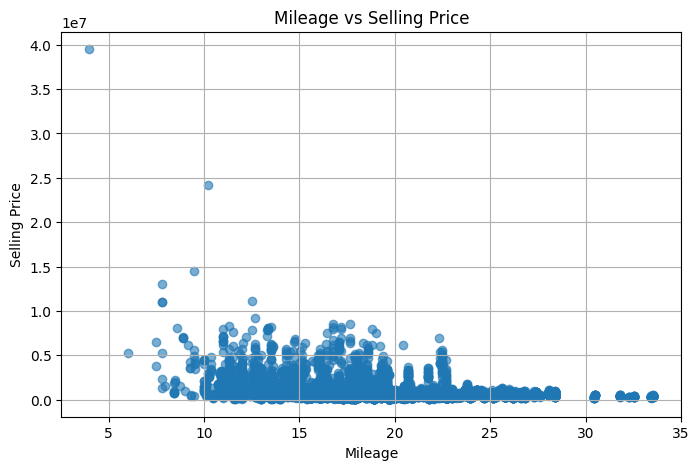

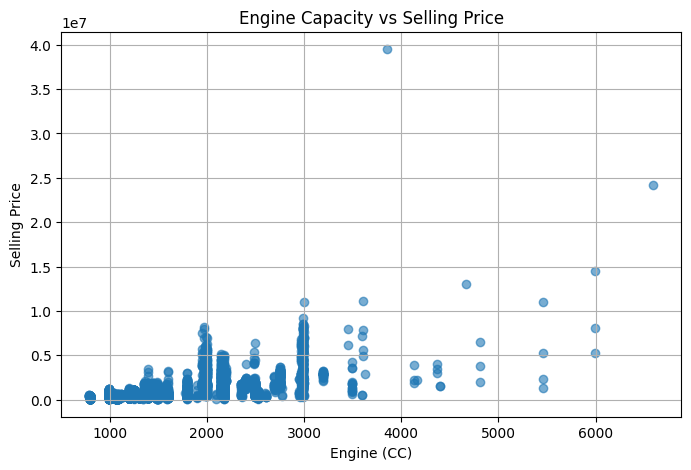

In [14]:
# Task 7: Exploratory Data Analysis

import matplotlib.pyplot as plt

# Convert required columns to numeric
df["selling_price"] = pd.to_numeric(df["selling_price"], errors="coerce")
df["mileage"] = pd.to_numeric(df["mileage"], errors="coerce")
df["engine"] = pd.to_numeric(df["engine"], errors="coerce")

# Remove rows with missing values in the columns used for plotting
eda_data = df[["selling_price", "mileage", "engine"]].dropna()

# --------------------------------------------------
# Scatter Plot 1: Mileage vs Selling Price
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    eda_data["mileage"],
    eda_data["selling_price"],
    alpha=0.6
)

plt.xlabel("Mileage")
plt.ylabel("Selling Price")
plt.title("Mileage vs Selling Price")
plt.grid(True)

plt.show()


# --------------------------------------------------
# Scatter Plot 2: Engine vs Selling Price
# --------------------------------------------------

plt.figure(figsize=(8, 5))

plt.scatter(
    eda_data["engine"],
    eda_data["selling_price"],
    alpha=0.6
)

plt.xlabel("Engine (CC)")
plt.ylabel("Selling Price")
plt.title("Engine Capacity vs Selling Price")
plt.grid(True)

plt.show()

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [15]:
# Task 8: Standardize Numerical Features

import numpy as np

# Separate target variable
y = df["selling_price"].copy()

# Numerical predictor columns
numerical_features = [
    "vehicle_age",
    "km_driven",
    "mileage",
    "engine",
    "max_power",
    "seats"
]

# Create feature matrix
X = df[numerical_features].copy()

# Convert all numerical features to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Remove rows containing missing values
valid_rows = X.notnull().all(axis=1)

X = X.loc[valid_rows].reset_index(drop=True)
y = y.loc[valid_rows].reset_index(drop=True)

# --------------------------------------------------
# Split data into training and testing sets
# --------------------------------------------------

# Use 80% training and 20% testing
np.random.seed(42)

indices = np.random.permutation(len(X))

train_size = int(0.80 * len(X))

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

# --------------------------------------------------
# Calculate mean and standard deviation using
# TRAINING DATA ONLY
# --------------------------------------------------

train_mean = X_train.mean()
train_std = X_train.std()

print("Training Mean:")
print(train_mean)

print("\nTraining Standard Deviation:")
print(train_std)

# --------------------------------------------------
# Standardize training features
# z = (x - mean) / standard deviation
# --------------------------------------------------

X_train_scaled = (X_train - train_mean) / train_std

# --------------------------------------------------
# Standardize test features using the SAME
# training mean and standard deviation
# --------------------------------------------------

X_test_scaled = (X_test - train_mean) / train_std

# --------------------------------------------------
# Display results
# --------------------------------------------------

print("\nStandardized Training Features:")
display(X_train_scaled.head())

print("\nStandardized Test Features:")
display(X_test_scaled.head())

# --------------------------------------------------
# Verify standardization
# --------------------------------------------------

print("\nTraining means after standardization:")
print(X_train_scaled.mean())

print("\nTraining standard deviations after standardization:")
print(X_train_scaled.std())

# Target variable remains unchanged
print("\nTarget variable:")
display(y_train.head())

print("\nTarget variable was NOT standardized.")

Training Mean:
vehicle_age        6.032446
km_driven      55692.819598
mileage           19.691552
engine          1485.037395
max_power        100.516747
seats              5.326249
dtype: float64

Training Standard Deviation:
vehicle_age        3.018870
km_driven      54473.163748
mileage            4.172802
engine           518.296985
max_power         42.745688
seats              0.809603
dtype: float64

Standardized Training Features:


,vehicle_age,km_driven,mileage,engine,max_power,seats
3334,1.976751,0.317719,0.160192,-0.555738,-0.505706,-0.402974
10928,-0.673248,0.042354,1.844911,-0.457339,-0.620337,-0.402974
2518,0.320502,0.739946,0.258447,-0.457339,-0.275039,2.067371
11322,-1.666997,-0.939781,-0.309517,0.025010,0.440588,-0.402974
9394,1.645501,0.115785,0.002025,-1.329426,-1.268356,-0.402974



Standardized Test Features:


,vehicle_age,km_driven,mileage,engine,max_power,seats
15384,-1.004497,-0.563448,-2.322552,1.279117,1.625503,-0.402974
147,0.651752,0.409508,-0.752864,0.931826,1.099368,-0.402974
1668,0.320502,0.124964,1.320084,-0.457339,-0.620337,-0.402974
11280,-0.341998,-0.563448,1.348841,-0.553809,-0.550155,0.832199
13650,-1.004497,-0.618521,-0.357446,-0.551879,-0.276443,-0.402974



Training means after standardization:
vehicle_age   -1.786731e-17
km_driven      3.342917e-17
mileage       -1.809786e-16
engine         2.132550e-17
max_power      7.665654e-17
seats         -1.083566e-16
dtype: float64

Training standard deviations after standardization:
vehicle_age    1.0
km_driven      1.0
mileage        1.0
engine         1.0
max_power      1.0
seats          1.0
dtype: float64

Target variable:


,selling_price
3334,190000
10928,600000
2518,665000
11322,1570000
9394,160000



Target variable was NOT standardized.


## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [17]:
# Task 9: Split the Dataset

import numpy as np

# Fixed random seed
np.random.seed(42)

# Total observations
n = len(X)

# Randomly shuffle indices
indices = np.random.permutation(n)

# 80:20 split
train_size = int(0.80 * n)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

# Split features
X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()

# Split target
y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

# Reset indices
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

# Counts
train_count = len(X_train)
test_count = len(X_test)

# Calculate percentages
train_percentage = (train_count / n) * 100
test_percentage = (test_count / n) * 100

# Display results
print("Dataset Split")
print("-------------------------")
print("Total observations :", n)
print("Training observations:", train_count)
print("Testing observations :", test_count)

print("\nTrain-Test Ratio:")
print("Training : Testing = 80 : 20")

print("\nActual Ratio:")
print(f"Training : Testing = {train_count} : {test_count}")

print("\nPercentage:")
print(f"Training = {train_percentage:.2f}%")
print(f"Testing  = {test_percentage:.2f}%")

print("\nShapes:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

Dataset Split
-------------------------
Total observations : 15411
Training observations: 12328
Testing observations : 3083

Train-Test Ratio:
Training : Testing = 80 : 20

Actual Ratio:
Training : Testing = 12328 : 3083

Percentage:
Training = 79.99%
Testing  = 20.01%

Shapes:
X_train: (12328, 6)
X_test : (3083, 6)
y_train: (12328,)
y_test : (3083,)


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [18]:
# Task 10: Construct the Feature Matrix

import numpy as np

# Create training feature matrix
Xtrain = np.array(X_train)

# Create training target vector
ytrain = np.array(y_train)

# Create testing feature matrix
Xtest = np.array(X_test)

# Create testing target vector
ytest = np.array(y_test)

# Display shapes
print("Training Feature Matrix (Xtrain):")
print("Shape:", Xtrain.shape)

print("\nTraining Target Vector (ytrain):")
print("Shape:", ytrain.shape)

print("\nTesting Feature Matrix (Xtest):")
print("Shape:", Xtest.shape)

print("\nTesting Target Vector (ytest):")
print("Shape:", ytest.shape)

# Number of rows
print("\nNumber of rows:")
print("Xtrain:", Xtrain.shape[0])
print("ytrain:", ytrain.shape[0])
print("Xtest :", Xtest.shape[0])
print("ytest :", ytest.shape[0])

# Number of predictor columns
print("\nNumber of predictor columns:")
print("Xtrain:", Xtrain.shape[1])
print("Xtest :", Xtest.shape[1])

# Verify dimensions
print("\nVerification:")

if Xtrain.shape[0] == ytrain.shape[0]:
    print("Training X and y have the same number of observations.")

if Xtest.shape[0] == ytest.shape[0]:
    print("Testing X and y have the same number of observations.")

if Xtrain.shape[1] == Xtest.shape[1]:
    print("Training and testing have the same number of predictor columns.")

Training Feature Matrix (Xtrain):
Shape: (12328, 6)

Training Target Vector (ytrain):
Shape: (12328,)

Testing Feature Matrix (Xtest):
Shape: (3083, 6)

Testing Target Vector (ytest):
Shape: (3083,)

Number of rows:
Xtrain: 12328
ytrain: 12328
Xtest : 3083
ytest : 3083

Number of predictor columns:
Xtrain: 6
Xtest : 6

Verification:
Training X and y have the same number of observations.
Testing X and y have the same number of observations.
Training and testing have the same number of predictor columns.


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [19]:
# Task 11: Add Bias/Intercept Term

import numpy as np

# Add a column of 1.0 to the beginning of Xtrain
Xtrain_bias = np.c_[np.ones(Xtrain.shape[0]), Xtrain]

# Add a column of 1.0 to the beginning of Xtest
Xtest_bias = np.c_[np.ones(Xtest.shape[0]), Xtest]

# Display the new dimensions
print("Original Xtrain shape:", Xtrain.shape)
print("Xtrain with bias shape:", Xtrain_bias.shape)

print("\nOriginal Xtest shape:", Xtest.shape)
print("Xtest with bias shape:", Xtest_bias.shape)

# Display first 5 rows
print("\nFirst 5 rows of Xtrain with bias:")
print(Xtrain_bias[:5])

print("\nFirst 5 rows of Xtest with bias:")
print(Xtest_bias[:5])

# Verify that the first column contains only 1.0
print("\nBias column verification:")

if np.all(Xtrain_bias[:, 0] == 1.0):
    print("Xtrain: Bias column successfully added.")

if np.all(Xtest_bias[:, 0] == 1.0):
    print("Xtest: Bias column successfully added.")

Original Xtrain shape: (12328, 6)
Xtrain with bias shape: (12328, 7)

Original Xtest shape: (3083, 6)
Xtest with bias shape: (3083, 7)

First 5 rows of Xtrain with bias:
[[1.0000e+00 1.2000e+01 7.3000e+04 2.0360e+01 1.1970e+03 7.8900e+01
  5.0000e+00]
 [1.0000e+00 4.0000e+00 5.8000e+04 2.7390e+01 1.2480e+03 7.4000e+01
  5.0000e+00]
 [1.0000e+00 7.0000e+00 9.6000e+04 2.0770e+01 1.2480e+03 8.8760e+01
  7.0000e+00]
 [1.0000e+00 1.0000e+00 4.5000e+03 1.8400e+01 1.4980e+03 1.1935e+02
  5.0000e+00]
 [1.0000e+00 1.1000e+01 6.2000e+04 1.9700e+01 7.9600e+02 4.6300e+01
  5.0000e+00]]

First 5 rows of Xtest with bias:
[[1.0000e+00 3.0000e+00 2.5000e+04 1.0000e+01 2.1480e+03 1.7000e+02
  5.0000e+00]
 [1.0000e+00 8.0000e+00 7.8000e+04 1.6550e+01 1.9680e+03 1.4751e+02
  5.0000e+00]
 [1.0000e+00 7.0000e+00 6.2500e+04 2.5200e+01 1.2480e+03 7.4000e+01
  5.0000e+00]
 [1.0000e+00 5.0000e+00 2.5000e+04 2.5320e+01 1.1980e+03 7.7000e+01
  6.0000e+00]
 [1.0000e+00 3.0000e+00 2.2000e+04 1.8200e+01 1.1990e+03 

## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [20]:
# Task 12: Implement Ordinary Least Squares (OLS)

import numpy as np

# Define the OLS function
def OLS(X, y):
    # Calculate X transpose
    XT = X.T

    # Calculate X^T X
    XTX = XT @ X

    # Calculate X^T y
    XTy = XT @ y

    # Calculate the inverse of X^T X
    XTX_inv = np.linalg.inv(XTX)

    # Calculate regression coefficients
    beta = XTX_inv @ XTy

    # Return coefficient vector
    return beta


# Calculate regression coefficients using training data
beta = OLS(Xtrain_bias, ytrain)

# Display the coefficient vector
print("Regression Coefficient Vector (Beta):")
print(beta)

# Display dimensions
print("\nShape of Xtrain:")
print(Xtrain_bias.shape)

print("\nShape of XTX:")
XTX = Xtrain_bias.T @ Xtrain_bias
print(XTX.shape)

print("\nShape of XTy:")
XTy = Xtrain_bias.T @ ytrain
print(XTy.shape)

print("\nShape of Beta:")
print(beta.shape)

Regression Coefficient Vector (Beta):
[-7.65870856e+05 -6.50147792e+04 -6.77550257e-01  1.37530571e+04
  7.58158512e+01  1.57543776e+04  8.57129320e+02]

Shape of Xtrain:
(12328, 7)

Shape of XTX:
(7, 7)

Shape of XTy:
(7,)

Shape of Beta:
(7,)


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [21]:
# Task 13: Check Matrix Singularity

import numpy as np

# Calculate X^T X
XTX = Xtrain_bias.T @ Xtrain_bias

# Calculate determinant
det_XTX = np.linalg.det(XTX)

print("X^T X Matrix:")
print(XTX)

print("\nDeterminant of X^T X:")
print(det_XTX)

# Define a small tolerance
tolerance = 1e-10

# Check whether the matrix is singular or nearly singular
if abs(det_XTX) < tolerance:
    print("\nResult: X^T X is singular or nearly singular.")
    print("The selected features may contain redundancy or multicollinearity.")
else:
    print("\nResult: X^T X is not singular.")
    print("The matrix can be used for the OLS calculation.")

# Calculate matrix rank
rank = np.linalg.matrix_rank(XTX)

print("\nMatrix Rank:")
print(rank)

print("\nNumber of columns in Xtrain_bias:")
print(Xtrain_bias.shape[1])

# Additional condition number check
condition_number = np.linalg.cond(XTX)

print("\nCondition Number:")
print(condition_number)

if condition_number > 1e10:
    print("Warning: X^T X may be poorly conditioned.")
else:
    print("X^T X is reasonably conditioned.")

X^T X Matrix:
[[1.23280000e+04 7.43680000e+04 6.86581080e+08 2.42757450e+05
  1.83075410e+07 1.23917046e+06 6.56620000e+04]
 [7.43680000e+04 5.60964000e+05 4.77914330e+09 1.42440640e+06
  1.12304551e+08 7.47466506e+06 3.97047000e+05]
 [6.86581080e+08 4.77914330e+09 7.48158585e+13 1.32306421e+10
  1.08544250e+12 7.02574380e+10 3.75928776e+09]
 [2.42757450e+05 1.42440640e+06 1.32306421e+10 4.99491204e+06
  3.43664005e+08 2.32305586e+07 1.27476741e+06]
 [1.83075410e+07 1.12304551e+08 1.08544250e+12 3.43664005e+08
  3.04988067e+10 2.05969110e+09 1.00365680e+08]
 [1.23917046e+06 7.47466506e+06 7.02574380e+10 2.32305586e+07
  2.05969110e+09 1.47081203e+08 6.67368955e+06]
 [6.56620000e+04 3.97047000e+05 3.75928776e+09 1.27476741e+06
  1.00365680e+08 6.67368955e+06 3.57812000e+05]]

Determinant of X^T X:
4.812491773078243e+47

Result: X^T X is not singular.
The matrix can be used for the OLS calculation.

Matrix Rank:
7

Number of columns in Xtrain_bias:
7

Condition Number:
1222348027225.2598

## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [22]:
# Task 14: Train the Regression Model

import numpy as np
import pandas as pd

# Apply OLS to the training dataset
beta = OLS(Xtrain_bias, ytrain)

# Display complete coefficient vector
print("Regression Coefficient Vector (Beta):")
print(beta)

# Display intercept
print("\nIntercept (β0):")
print(beta[0])

# Get feature names
feature_names = X_train.columns.tolist()

# Create coefficient table
coefficient_table = pd.DataFrame({
    "Feature": ["Intercept"] + feature_names,
    "Coefficient": beta
})

# Display coefficients associated with features
print("\nRegression Coefficients:")
display(coefficient_table)

Regression Coefficient Vector (Beta):
[-7.65870856e+05 -6.50147792e+04 -6.77550257e-01  1.37530571e+04
  7.58158512e+01  1.57543776e+04  8.57129320e+02]

Intercept (β0):
-765870.855685398

Regression Coefficients:


,Feature,Coefficient
0,Intercept,-765870.855685
1,vehicle_age,-65014.779175
2,km_driven,-0.677550
3,mileage,13753.057078
4,engine,75.815851
5,max_power,15754.377629
6,seats,857.129320


## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [23]:
# Task 15: Interpret the Regression Coefficients

import pandas as pd
import numpy as np

# Get feature names
feature_names = X_train.columns.tolist()

# Create coefficient table
interpretation = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": beta[1:]
})

# Identify positive/negative coefficients
interpretation["Direction"] = np.where(
    interpretation["Coefficient"] >= 0,
    "Positive",
    "Negative"
)

# Absolute coefficient for comparing influence
interpretation["Absolute_Coefficient"] = interpretation["Coefficient"].abs()

# Sort by magnitude of coefficient
interpretation = interpretation.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("Regression Coefficient Interpretation:")
display(interpretation)

# Display intercept separately
print("\nIntercept (β0):")
print(beta[0])

# Display positive coefficients
print("\nPositive Coefficients:")
for _, row in interpretation[interpretation["Direction"] == "Positive"].iterrows():
    print(f"{row['Feature']}: {row['Coefficient']:.4f}")

# Display negative coefficients
print("\nNegative Coefficients:")
for _, row in interpretation[interpretation["Direction"] == "Negative"].iterrows():
    print(f"{row['Feature']}: {row['Coefficient']:.4f}")

# Most influential features based on absolute coefficient
print("\nFeatures with relatively greater influence:")
display(
    interpretation[
        ["Feature", "Coefficient", "Direction", "Absolute_Coefficient"]
    ].head(10)
)

Regression Coefficient Interpretation:


,Feature,Coefficient,Direction,Absolute_Coefficient
0,vehicle_age,-65014.779175,Negative,65014.779175
4,max_power,15754.377629,Positive,15754.377629
2,mileage,13753.057078,Positive,13753.057078
5,seats,857.129320,Positive,857.129320
3,engine,75.815851,Positive,75.815851
1,km_driven,-0.677550,Negative,0.677550



Intercept (β0):
-765870.855685398

Positive Coefficients:
max_power: 15754.3776
mileage: 13753.0571
seats: 857.1293
engine: 75.8159

Negative Coefficients:
vehicle_age: -65014.7792
km_driven: -0.6776

Features with relatively greater influence:


,Feature,Coefficient,Direction,Absolute_Coefficient
0,vehicle_age,-65014.779175,Negative,65014.779175
4,max_power,15754.377629,Positive,15754.377629
2,mileage,13753.057078,Positive,13753.057078
5,seats,857.129320,Positive,857.129320
3,engine,75.815851,Positive,75.815851
1,km_driven,-0.677550,Negative,0.677550


## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [24]:
# Task 16: Predict Selling Prices

import numpy as np
import pandas as pd

# Use the test matrix with the bias/intercept column
# Xtest_bias was created in Task 11

# Calculate predicted selling prices
y_pred = Xtest_bias @ beta

# Display the first few predictions
print("First 10 Predicted Selling Prices:")
print(y_pred[:10])

# Create a comparison table
comparison = pd.DataFrame({
    "Actual Selling Price": ytest[:10],
    "Predicted Selling Price": y_pred[:10]
})

print("\nActual vs Predicted Selling Prices:")
display(comparison)

First 10 Predicted Selling Prices:
[2005058.91302346 1366194.57127365  347983.61080247  549401.14030612
  767086.48782156 -613820.03789587  842369.61761743 -157007.17600437
  404467.19436781  776216.91768327]

Actual vs Predicted Selling Prices:


,Actual Selling Price,Predicted Selling Price
0,4450000,2.005059e+06
1,1290000,1.366195e+06
2,485000,3.479836e+05
3,400000,5.494011e+05
4,800000,7.670865e+05
5,150000,-6.138200e+05
6,650000,8.423696e+05
7,325000,-1.570072e+05
8,300000,4.044672e+05
9,925000,7.762169e+05


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [25]:
# Task 17: Calculate Prediction Errors and RSS

import numpy as np
import pandas as pd

# Calculate residuals
# Residual = Actual value - Predicted value
residuals = ytest - y_pred

# Calculate RSS
RSS = np.sum(residuals ** 2)

# Display first 10 residuals
print("First 10 Prediction Errors (Residuals):")
print(residuals[:10])

# Create a table showing actual, predicted and residual values
error_table = pd.DataFrame({
    "Actual Selling Price": ytest,
    "Predicted Selling Price": y_pred,
    "Residual": residuals
})

print("\nSample Prediction Error Table:")
display(error_table.head(10))

# Display RSS
print("\nResidual Sum of Squares (RSS):")
print(RSS)

First 10 Prediction Errors (Residuals):
[2444941.08697654  -76194.57127365  137016.38919753 -149401.14030612
   32913.51217844  763820.03789587 -192369.61761743  482007.17600437
 -104467.19436781  148783.08231673]

Sample Prediction Error Table:


,Actual Selling Price,Predicted Selling Price,Residual
0,4450000,2.005059e+06,2.444941e+06
1,1290000,1.366195e+06,-7.619457e+04
2,485000,3.479836e+05,1.370164e+05
3,400000,5.494011e+05,-1.494011e+05
4,800000,7.670865e+05,3.291351e+04
5,150000,-6.138200e+05,7.638200e+05
6,650000,8.423696e+05,-1.923696e+05
7,325000,-1.570072e+05,4.820072e+05
8,300000,4.044672e+05,-1.044672e+05
9,925000,7.762169e+05,1.487831e+05



Residual Sum of Squares (RSS):
892945834721059.6


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [26]:
# Task 18: Calculate and Interpret R²

import numpy as np

# Calculate the mean of actual test selling prices
y_test_mean = np.mean(ytest)

# Calculate Total Sum of Squares (TSS)
TSS = np.sum((ytest - y_test_mean) ** 2)

# Calculate R²
R2 = 1 - (RSS / TSS)

# Display TSS
print("Total Sum of Squares (TSS):")
print(TSS)

# Display RSS
print("\nResidual Sum of Squares (RSS):")
print(RSS)

# Display R²
print("\nR² (R-squared):")
print(R2)

# Display R² as percentage
print("\nPercentage of variation explained:")
print(f"{R2 * 100:.2f}%")

Total Sum of Squares (TSS):
2407385049859876.5

Residual Sum of Squares (RSS):
892945834721059.6

R² (R-squared):
0.6290805931635098

Percentage of variation explained:
62.91%


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


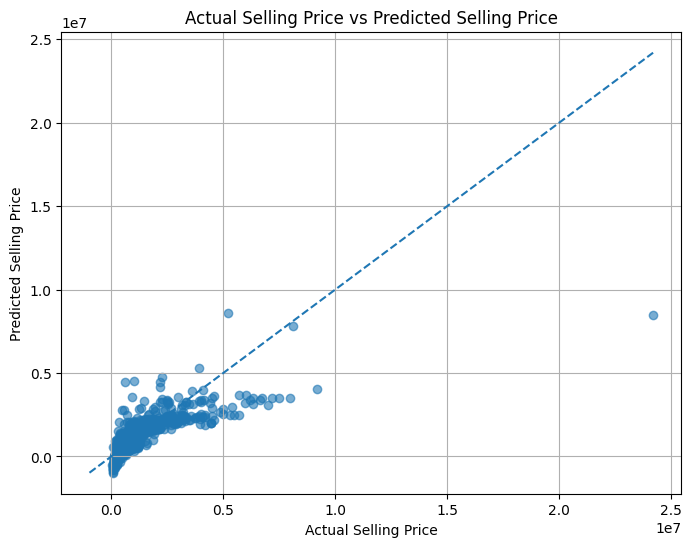

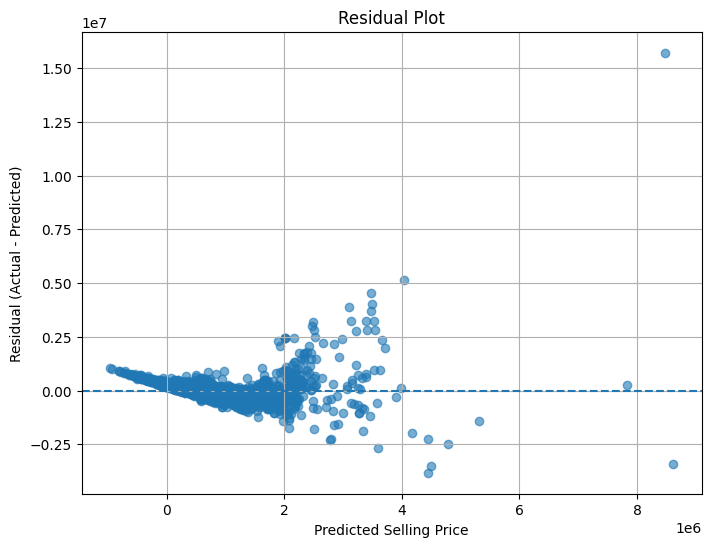

10 observations with the largest prediction errors:


,Actual Selling Price,Predicted Selling Price,Residual,Absolute Error
2796,24200000,8.483885e+06,1.571612e+07,1.571612e+07
2362,9200000,4.036108e+06,5.163892e+06,5.163892e+06
1382,8000000,3.477296e+06,4.522704e+06,4.522704e+06
841,7500000,3.481968e+06,4.018032e+06,4.018032e+06
246,7000000,3.092218e+06,3.907782e+06,3.907782e+06
26,625000,4.449522e+06,-3.824522e+06,3.824522e+06
1286,7199000,3.477296e+06,3.721704e+06,3.721704e+06
2528,999000,4.497734e+06,-3.498734e+06,3.498734e+06
2050,5200000,8.617762e+06,-3.417762e+06,3.417762e+06
1092,6645000,3.388240e+06,3.256760e+06,3.256760e+06


Error Analysis
-------------------------
Mean Absolute Error:
270044.52345451905

Maximum Absolute Error:
15716115.328019934

Minimum Absolute Error:
169.71655386558268


In [27]:
# Task 19: Visualize and Analyze Model Performance

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------
# 1. Actual Selling Price vs Predicted Selling Price
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(ytest, y_pred, alpha=0.6)

# Perfect prediction reference line
min_value = min(ytest.min(), y_pred.min())
max_value = max(ytest.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual Selling Price vs Predicted Selling Price")
plt.grid(True)

plt.show()


# --------------------------------------------------
# 2. Residual Plot
# --------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(y_pred, residuals, alpha=0.6)

# Zero-error reference line
plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Selling Price")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Residual Plot")
plt.grid(True)

plt.show()


# --------------------------------------------------
# 3. Identify observations with large errors
# --------------------------------------------------

error_analysis = pd.DataFrame({
    "Actual Selling Price": ytest,
    "Predicted Selling Price": y_pred,
    "Residual": residuals,
    "Absolute Error": np.abs(residuals)
})

# Sort by absolute error
large_errors = error_analysis.sort_values(
    by="Absolute Error",
    ascending=False
)

print("10 observations with the largest prediction errors:")
display(large_errors.head(10))


# --------------------------------------------------
# 4. Calculate error statistics
# --------------------------------------------------

print("Error Analysis")
print("-------------------------")

print("Mean Absolute Error:")
print(np.mean(np.abs(residuals)))

print("\nMaximum Absolute Error:")
print(np.max(np.abs(residuals)))

print("\nMinimum Absolute Error:")
print(np.min(np.abs(residuals)))

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


In [31]:
# Task 20: Final Numerical Results

import pandas as pd
import numpy as np

# Get feature names
feature_names = X_train.columns.tolist()

# Create coefficient table
importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": beta[1:]
})

# Calculate absolute coefficient magnitude
importance["Absolute_Coefficient"] = importance["Coefficient"].abs()

# Sort by importance
importance = importance.sort_values(
    by="Absolute_Coefficient",
    ascending=False
).reset_index(drop=True)

# Get most influential feature
most_influential = importance.iloc[0]

print("=" * 60)
print("FINAL MODEL RESULTS")
print("=" * 60)

print("\nMost Influential Feature:")
print("Feature:", most_influential["Feature"])
print("Coefficient:", most_influential["Coefficient"])

# Display top 5 influential features
print("\nTop 5 Most Influential Features:")
display(importance.head(5))

# Display model performance
print("\nModel Performance:")
print("RSS:", RSS)
print("TSS:", TSS)
print("R²:", R2)
print("R² Percentage:", f"{R2 * 100:.2f}%")

# Display intercept
print("\nIntercept (β0):")
print(beta[0])

FINAL MODEL RESULTS

Most Influential Feature:
Feature: vehicle_age
Coefficient: -65014.77917516278

Top 5 Most Influential Features:


,Feature,Coefficient,Absolute_Coefficient
0,vehicle_age,-65014.779175,65014.779175
1,max_power,15754.377629,15754.377629
2,mileage,13753.057078,13753.057078
3,seats,857.129320,857.129320
4,engine,75.815851,75.815851



Model Performance:
RSS: 892945834721059.6
TSS: 2407385049859876.5
R²: 0.6290805931635098
R² Percentage: 62.91%

Intercept (β0):
-765870.855685398


### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.